In [7]:
import hdf5plugin 
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
h5_path = r"/store1/lauren/HeatTests/2025-12-11-05.h5"

def list_image_datasets(f):
    candidates = []
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset) and obj.ndim in (3, 4):
            candidates.append(name)
            print(f"Found dataset: '{name}'  shape={obj.shape}  dtype={obj.dtype}")
    f.visititems(visitor)
    if not candidates:
        raise RuntimeError("No 3D/4D datasets found.")
    return candidates

with h5py.File(h5_path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    candidates = list_image_datasets(f)

    chosen_name = "img_nir"
    ds = f[chosen_name]
    print(f"\nUsing dataset: '{chosen_name}'  shape={ds.shape}  dtype={ds.dtype}")
    frames = ds[...]   # this is the line that should now succeed

print("Loaded frames:", frames.shape, frames.dtype)


Top-level keys: ['cooling_laser_x', 'cooling_laser_y', 'cooling_record', 'cooling_zero_left_x', 'cooling_zero_left_y', 'cooling_zero_right_x', 'cooling_zero_right_y', 'daqmx_ai', 'daqmx_di', 'img_metadata', 'img_nir', 'laser_record', 'metadata', 'pos_feature', 'pos_stage', 'recording_start']
Found dataset: 'cooling_record'  shape=(2, 1, 614)  dtype=float64
Found dataset: 'img_nir'  shape=(5019, 732, 968)  dtype=uint8
Found dataset: 'laser_record'  shape=(3, 1, 502)  dtype=float64
Found dataset: 'pos_feature'  shape=(5019, 3, 3)  dtype=float32

Using dataset: 'img_nir'  shape=(5019, 732, 968)  dtype=uint8
Loaded frames: (5019, 732, 968) uint8


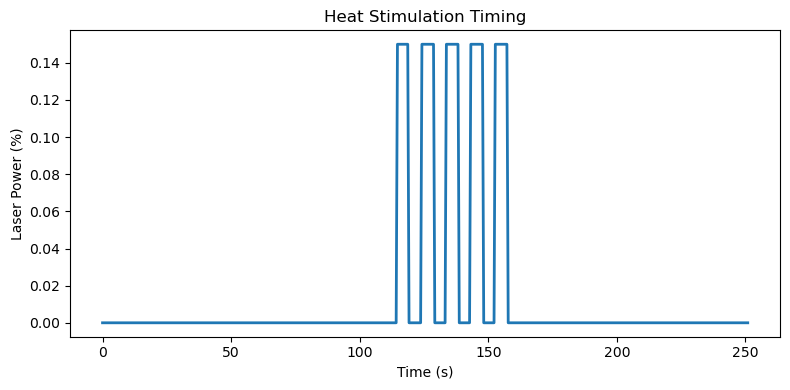

In [3]:
# --- set fps ---
fps = 20

# --- load laser_record and squeeze to (3, 502) ---
with h5py.File(h5_path, "r") as f:
    laser_ds = f["laser_record"]      # shape (3, 1, 502)
    laser = np.squeeze(laser_ds[()])  # -> (3, 502)

laser_ch1 = laser[1]                  # channel 1
num_samples = laser_ch1.shape[0]

# --- compute time axis in seconds, matched to video duration ---
num_frames = frames.shape[0]          # e.g. 5019
total_duration = (num_frames - 1) / fps   # seconds, ~250.95
t = np.linspace(0, total_duration, num_samples)  # shape (502,)

plt.figure(figsize=(8, 4))
plt.plot(t, laser_ch1, label="channel 1", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Laser Power (%)")
plt.title("Heat Stimulation Timing")
plt.tight_layout()
plt.show()


In [4]:
# --- load laser_record and extract channel 2 (binary heat stim) ---
with h5py.File(h5_path, "r") as f:
    laser_ds = f["laser_record"]      # shape (3, 1, 502)
    laser = np.squeeze(laser_ds[()])  # -> (3, 502)

# NOTE: channel index is 0-based here:
#   channel 0 -> laser[0]
#   channel 1 -> laser[1]
#   channel 2 -> laser[2]
laser_ch2 = laser[1]                  # "channel 1" binary heat stim
num_samples = laser_ch2.shape[0]

# number of video frames
num_frames = frames.shape[0]


def frame_has_heat_stim(frame_idx: int) -> bool:
    """
    Return True if this video frame is during a heat stimulus, based on
    laser_record channel 2. Any sample > 0.01 is considered 'laser ON'.
    """
    if num_frames <= 1:
        sample_idx = 0
    else:
        # linearly map frame index [0..num_frames-1] to laser sample index [0..num_samples-1]
        sample_idx = int(round(frame_idx * (num_samples - 1) / (num_frames - 1)))

    # clamp for safety
    sample_idx = max(0, min(num_samples - 1, sample_idx))

    return laser_ch2[sample_idx] > 0.01


def add_heat_stim_overlay(frame: np.ndarray, frame_idx: int, position=(20, 40)):
    """
    Add 'heat stim' text in pink for frames where laser channel 2 is ON.

    frame : 2D (H, W) or 3D (H, W, 3) numpy array
    frame_idx : 0-based index of the frame in the video
    position : (x, y) text position in pixels
    """
    # Ensure 3-channel BGR for OpenCV
    if frame.ndim == 2 or (frame.ndim == 3 and frame.shape[2] == 1):
        disp = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    else:
        disp = frame.copy()

    if frame_has_heat_stim(frame_idx):
        text = "heat stim"
        pink = (255, 160, 160)  # Prism Pale Red B3
        cv2.putText(
            disp,
            text,
            position,
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,           # font scale
            pink,
            2,             # thickness
            cv2.LINE_AA,
        )

    return disp


In [8]:
# Build output path in the same folder as the .h5
out_dir = os.path.dirname(h5_path)
out_path = os.path.join(out_dir, "output_with_heat_stim.mp4")
print("Saving video to:", out_path)



Saving video to: /store1/lauren/HeatTests/output_with_heat_stim.mp4


In [9]:
height, width = frames.shape[1:3]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

print("Video writer opened:", out.isOpened())

for i, frame in enumerate(frames):
    frame_with_text = add_heat_stim_overlay(frame, i)
    out.write(frame_with_text)

out.release()
print("Done.")

Video writer opened: True
Done.


In [6]:
#final_path = os.path.join(out_dir, "final_slide_video.mp4")
#!ffmpeg -y -i "{out_path}" -vcodec libx264 -crf 18 -preset veryslow -pix_fmt yuv420p "{final_path}"
#print("Final slide video:", final_path)
